In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🔍 Exploratory Data Analysis - Customer Churn")
print("============================================")

🔍 Exploratory Data Analysis - Customer Churn


In [4]:
df = pd.read_csv('../Data/Processed/churn_ml_dataset.csv')
print(f"📊 Dataset loaded: {df.shape}")

📊 Dataset loaded: (7032, 26)


In [5]:
print("\n📈 Basic Statistics:")
print(f"Churn Rate: {df['Target'].mean()*100:.2f}%")
print(f"Total Customers: {len(df)}")
print(f"Features: {len(df.columns)}")


📈 Basic Statistics:
Churn Rate: 26.58%
Total Customers: 7032
Features: 26


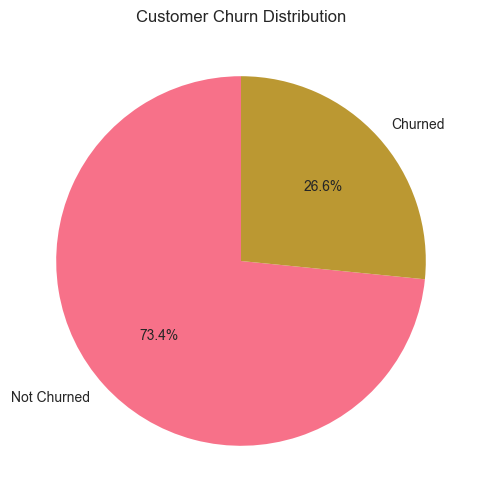

In [6]:
plt.figure(figsize=(10, 6))
churn_counts = df['Target'].value_counts()
plt.pie(churn_counts, labels=['Not Churned', 'Churned'], autopct='%1.1f%%', startangle=90)
plt.title('Customer Churn Distribution')
plt.show()

In [7]:
print("\n🔢 Numerical Features Summary:")
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(df[numerical_cols].describe())


🔢 Numerical Features Summary:
       Monthly_Charges  Total_Charges  Tenure_Months  Internet_Usage_GB  \
count      7032.000000    7032.000000    7032.000000        7032.000000   
mean         64.798208    2283.300441      32.421786          46.715968   
std          30.085974    2266.771362      24.545260          41.424615   
min          18.250000      18.800000       1.000000           0.000000   
25%          35.587500     401.450000       9.000000           8.965000   
50%          70.350000    1397.475000      29.000000          24.380000   
75%          89.862500    3794.737500      55.000000          89.057500   
max         118.750000    8684.800000      72.000000         131.430000   

       Calls_Minutes  Customer_Satisfaction_Score  
count    7032.000000                  7032.000000  
mean      226.912543                     7.052489  
std       110.976539                     1.864953  
min         0.000000                     1.000000  
25%       166.000000             

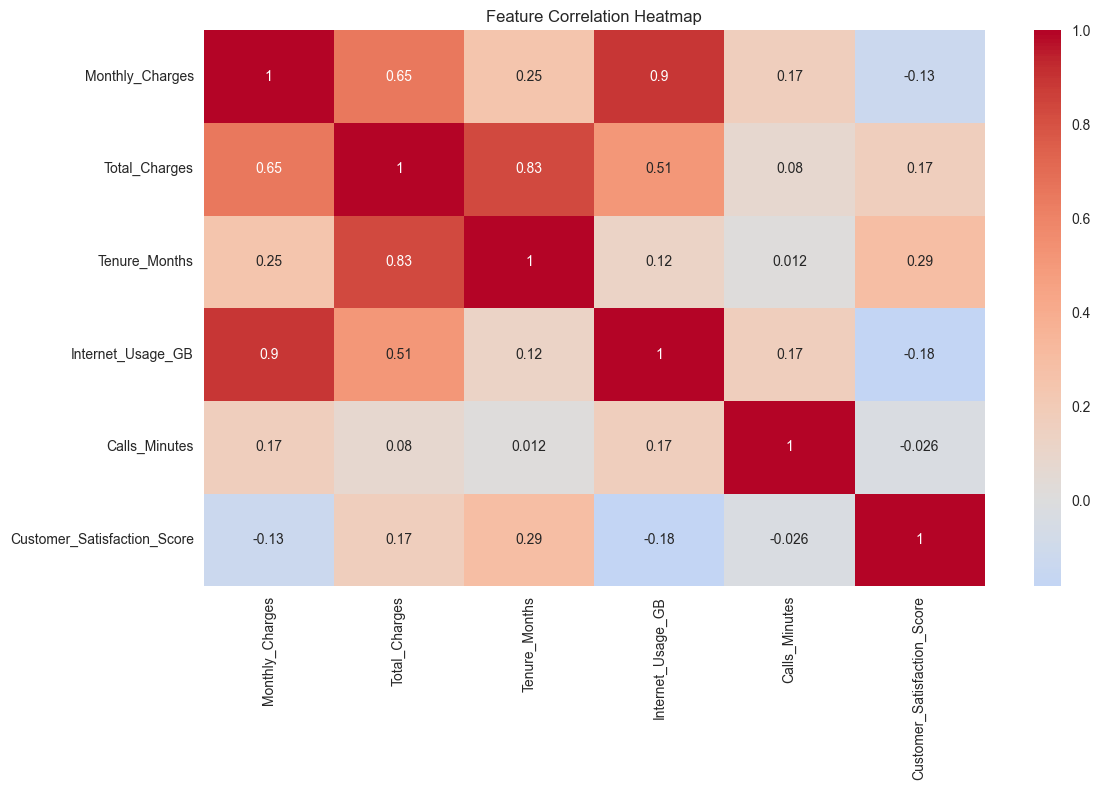

In [8]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../Reports/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

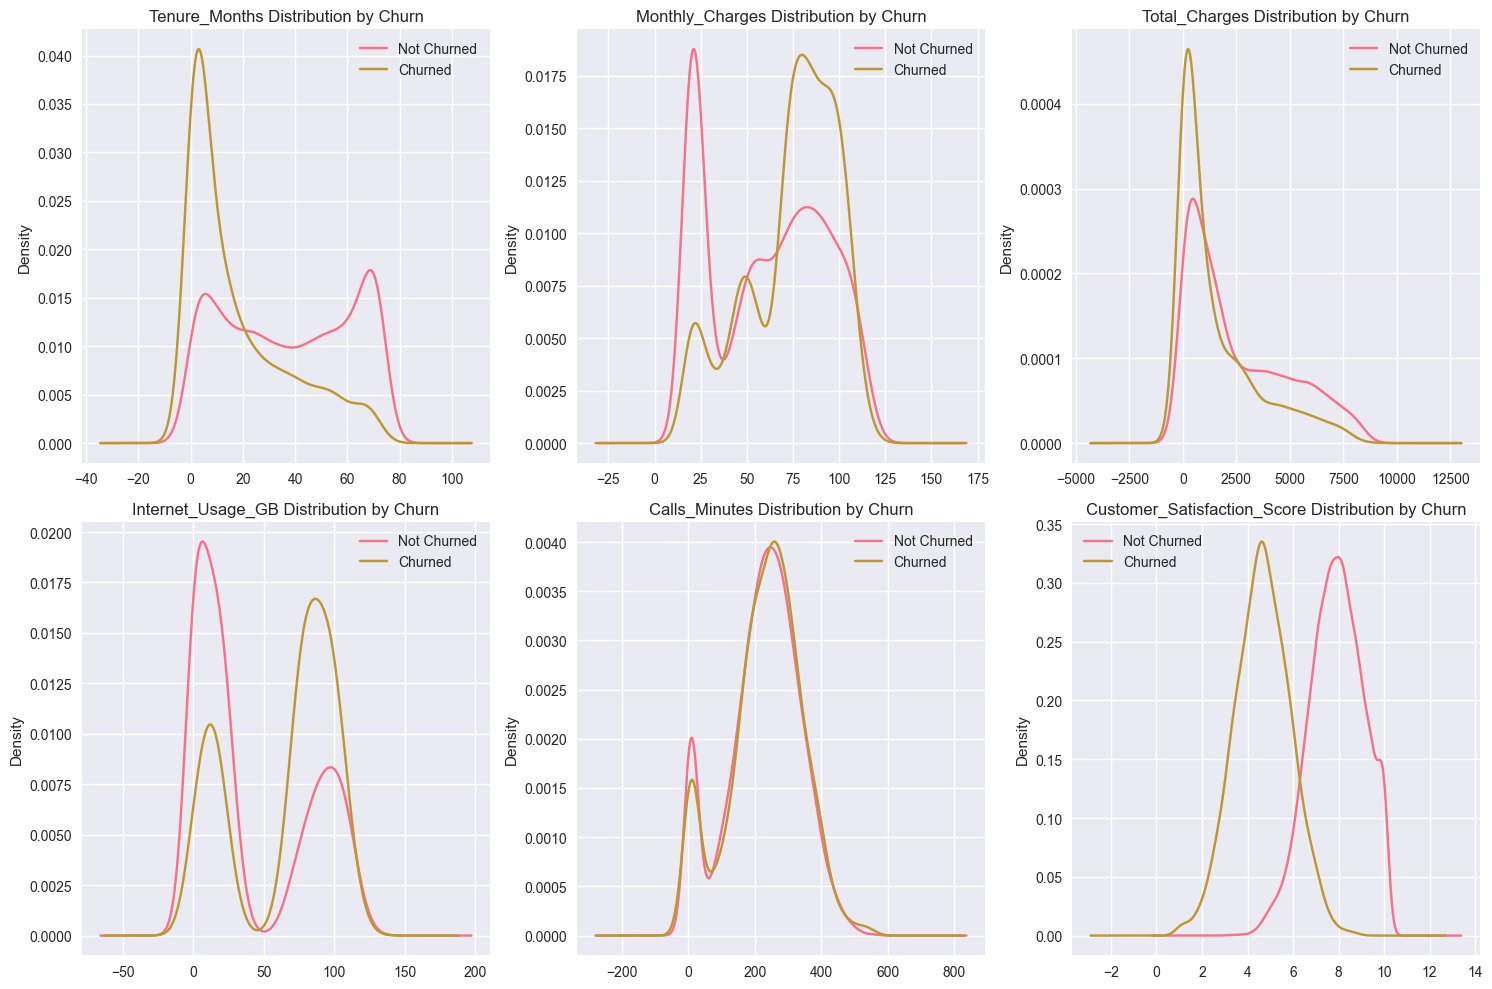

✅ EDA COMPLETED! Check ../Reports/ for saved plots.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numerical_to_plot = ['Tenure_Months', 'Monthly_Charges', 'Total_Charges', 
                     'Internet_Usage_GB', 'Calls_Minutes', 'Customer_Satisfaction_Score']

for i, col in enumerate(numerical_to_plot):
    if col in df.columns:
        ax = axes[i//3, i%3]
        df.groupby('Target')[col].plot(kind='kde', ax=ax, legend=True)
        ax.set_title(f'{col} Distribution by Churn')
        ax.legend(['Not Churned', 'Churned'])

plt.tight_layout()
plt.savefig('../Reports/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ EDA COMPLETED! Check ../Reports/ for saved plots.")